# Tracking Data Analysis
Reload and analyze time_tracking data from saved CSVs

In [479]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt

from slab_qick_calib.calib.time_tracking import load_tracking
from slab_qick_calib.analysis import collections, allan, qubit_params
from slab_qick_calib.helpers import config
from slab_qick_calib.helpers import handy
%matplotlib inline
handy.config_figs()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configuration

In [480]:
cfg_file = 'sample_50_rfboard.yml'
expt_path = r'C:\_Data\sample_50_new'
cfg_path = os.path.join(os.getcwd(), '..', 'configs', cfg_file)

csv_dir = os.path.join(expt_path, 'Tracking', 'csv')
qubit_list = [0]

## Load tracking data from CSVs

In [481]:
tt, csv_pth, tt_stats, tracking_id = load_tracking(csv_dir)

Loaded tracking_id='2026_03_23_20_37_0.5hrs', qubits=[2]
  CSV last updated: 2026-03-23 21:07:56 (0h 38m ago)


## Process data and add derived quantities

In [482]:
tt, tt_ave = collections.process_data(tt)
tt = collections.add_losses(tt)

 C:\_Lib\python\qq\slab_qick_calib\analysis\collections.py: 256RuntimeWarning: Degrees of freedom <= 0 for slice.
 c:\Users\circu\anaconda3\envs\qick_calib\Lib\site-packages\numpy\lib\_nanfunctions_impl.py: 2053

In [483]:
tt_ave

{'t1_mn': array([0.48155864]),
 't1_std': array([0.28971597]),
 't1_off_mn': array([-17.64565181]),
 't1_off_std': array([1.51003976]),
 't1_amp_mn': array([6.92260667]),
 't1_amp_std': array([1.03312635]),
 't2_off_mn': array([-13.61695649]),
 't2_off_std': array([1.02961087]),
 't2_amp_mn': array([-2.52420124]),
 't2_amp_std': array([3.75268025]),
 't2_mn': array([0.19620475]),
 't2_std': array([0.04341493]),
 'f_ge_mn': array([3370.97580387]),
 'f_ge_std': array([2.60228972]),
 't2_err_mn': array([0.04191796]),
 't2_err_std': array([0.01830998]),
 'fge_err_mn': array([0.16249613]),
 'fge_err_std': array([0.08943432]),
 't1_err_mn': array([0.19997249]),
 't1_err_std': array([1.03575605]),
 't1_r2_mn': array([0.81207084]),
 't1_r2_std': array([0.07322128]),
 't2_r2_mn': array([0.75540839]),
 't2_r2_std': array([0.08001186]),
 'time_mn': array([1.77432437e+09]),
 'time_std': array([520.885101]),
 'elapsed_mn': array([0.24992443]),
 'elapsed_std': array([0.14469026]),
 'mxc_temp_mn': ar

## Allan variance analysis

Combined fit failed: Optimal parameters not found: Number of calls to function has reached maxfev = 1000.


 C:\_Lib\python\qq\slab_qick_calib\analysis\allan.py: 16

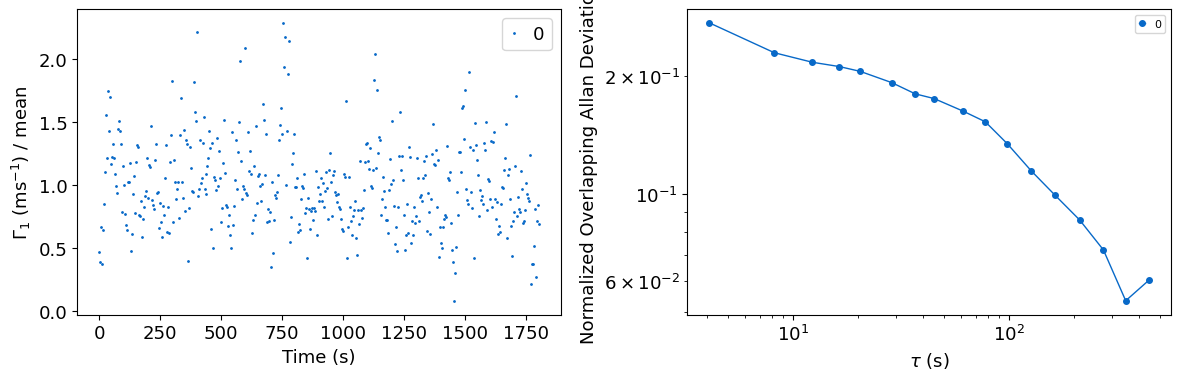

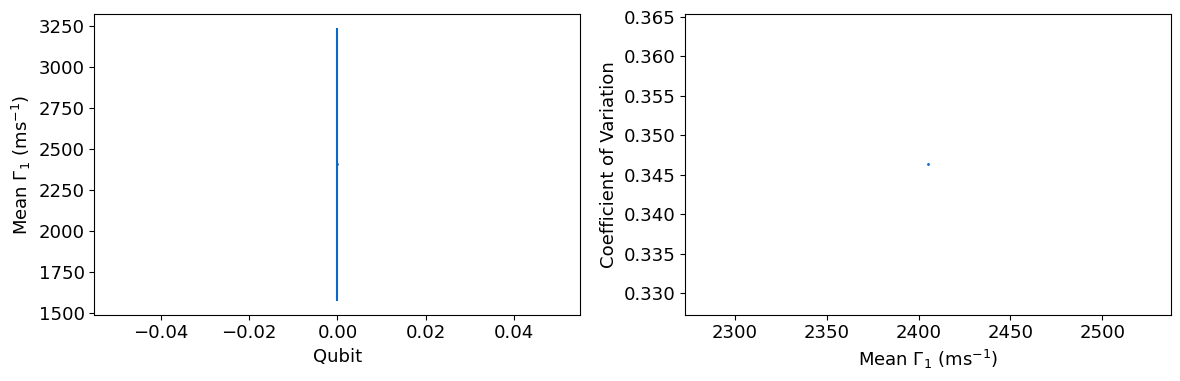

In [484]:

allan.perform_analysis(tt, param='Gamma1', save_path=csv_pth, tracking_id=tracking_id, normalize=True)


## Allan analysis (allantools)

Enhanced Allan deviation analysis using the `allantools` package.

### Deviation types

| Abbreviation | Name | Description |
|---|---|---|
| **ADEV** | Allan Deviation | Standard two-sample deviation. Most common stability measure. |
| **OADEV** | Overlapping Allan Deviation | Uses overlapping samples for better confidence at long tau. Same expectation as ADEV but lower variance. |
| **MDEV** | Modified Allan Deviation | Can distinguish white PM from flicker PM noise (ADEV cannot). |
| **HDEV** | Hadamard Deviation | Insensitive to linear frequency drift — useful when drift dominates. |
| **OHDEV** | Overlapping Hadamard Deviation | Overlapping version of HDEV. |
| **TDEV** | Time Deviation | Derived from MDEV; characterizes time stability rather than frequency stability. |
| **TOTDEV** | Total Deviation | Extends analysis to longer tau by reflecting data at boundaries. |

### Noise types (from log-log slope of ADEV vs tau)

| Abbreviation | Name | ADEV slope | Physical origin (qubit context) |
|---|---|---|---|
| **WPM** | White Phase Modulation | -1 | Measurement noise, digitization |
| **FPM** | Flicker Phase Modulation | -1 (same as WPM for ADEV) | Low-frequency measurement artifacts |
| **WFM** | White Frequency Modulation | -1/2 | Uncorrelated shot-to-shot fluctuations (e.g. photon shot noise, thermal noise) |
| **FFM** | Flicker Frequency Modulation | 0 (flat) | 1/f noise — TLS defects, charge noise, flux noise |
| **RWFM** | Random Walk Frequency Modulation | +1/2 | Diffusive drift — slow temperature or field drifts |

A slope that flattens or rises at long tau typically indicates correlated (1/f) or drifting noise, while a -1/2 slope indicates white (uncorrelated) fluctuations.


Gamma1
Qubit 0: lorentz_two fit failed: Optimal parameters not found: Number of calls to function has reached maxfev = 1000.


 C:\_Lib\python\qq\slab_qick_calib\analysis\allan.py: 16

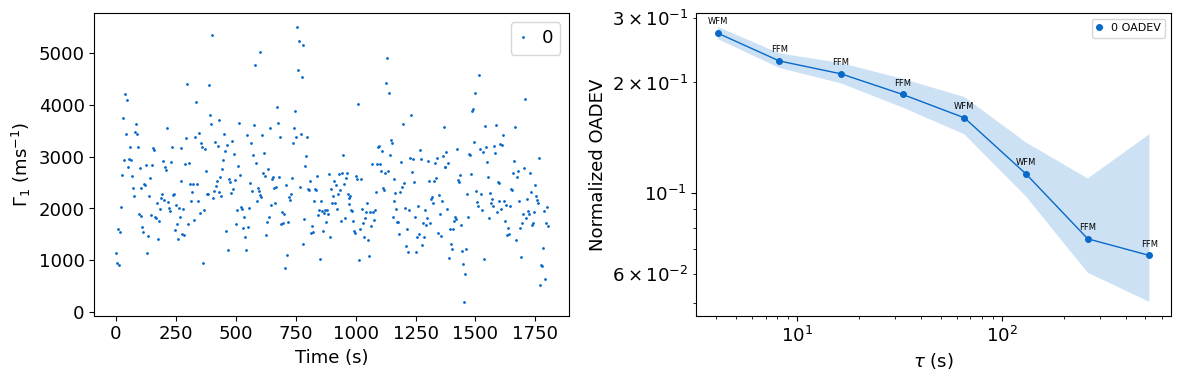

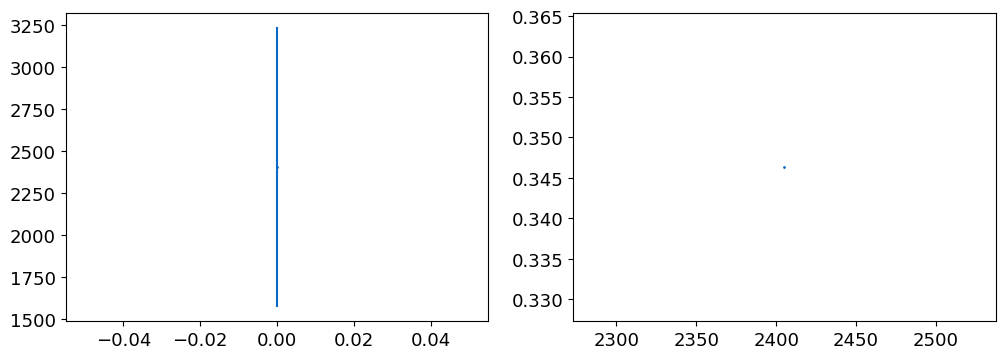


t1


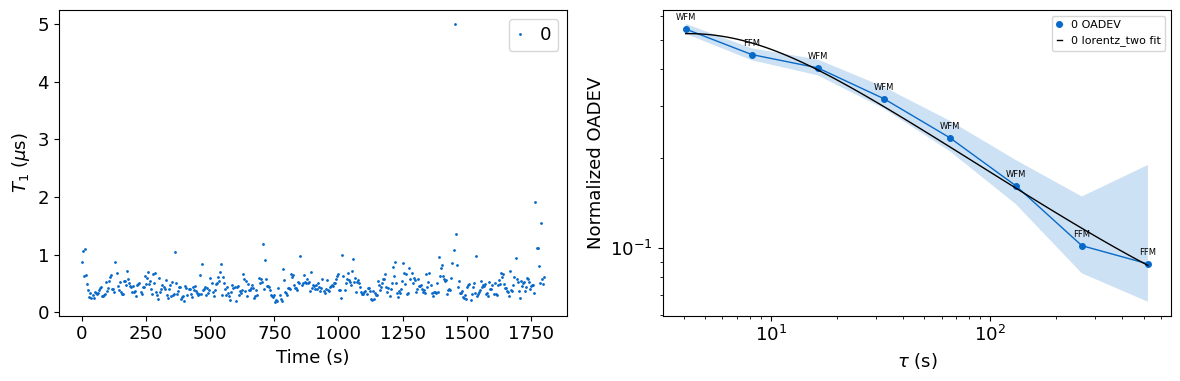

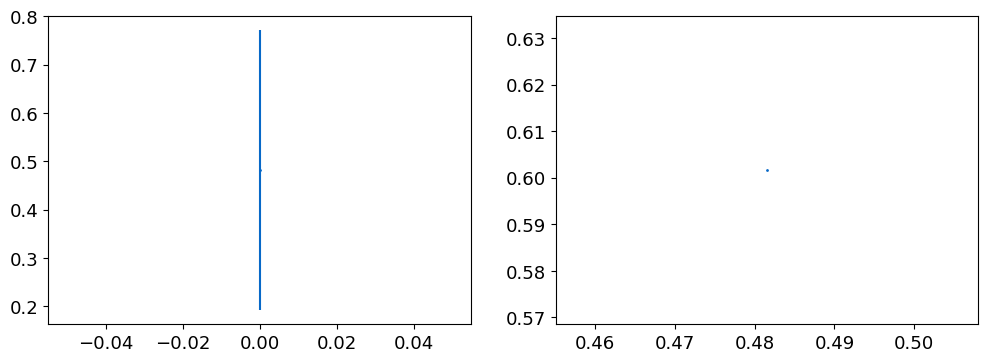


f_ge


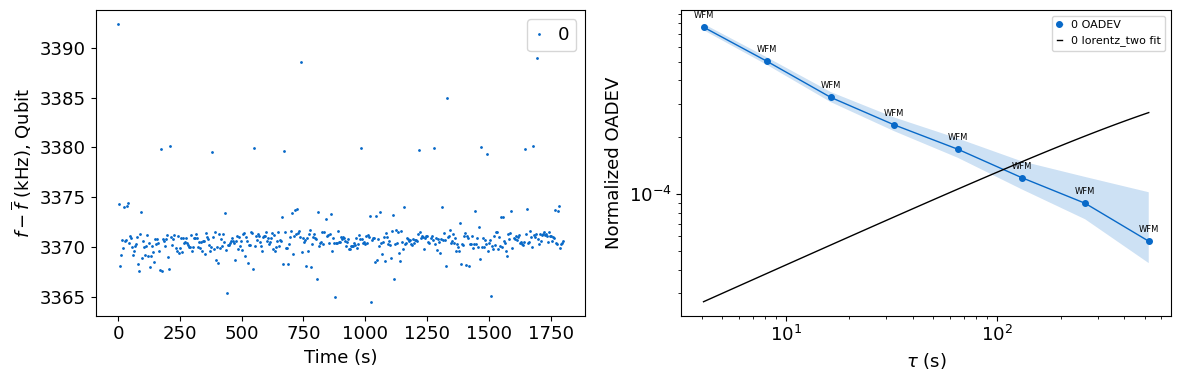

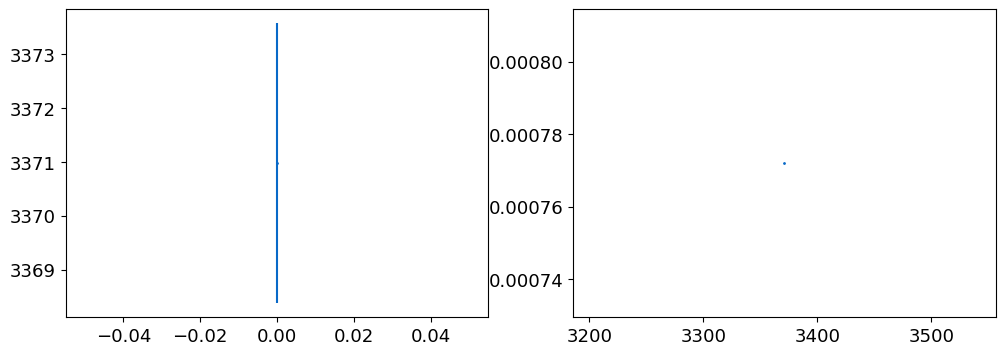

In [485]:
from slab_qick_calib.analysis.allan_at import perform_analysis_at, plot_deviation_comparison

# Full analysis per parameter with OADEV + fit
for param in ['Gamma1', 't1', 'f_ge']:
    print(f"\n{'='*60}\n{param}\n{'='*60}")
    perform_analysis_at(
        tt, param=param,
        dev_types=('oadev',), taus='octave',
        fit_models=('lorentz_two',),
        show_ci=True, show_noise_id=True,
    )

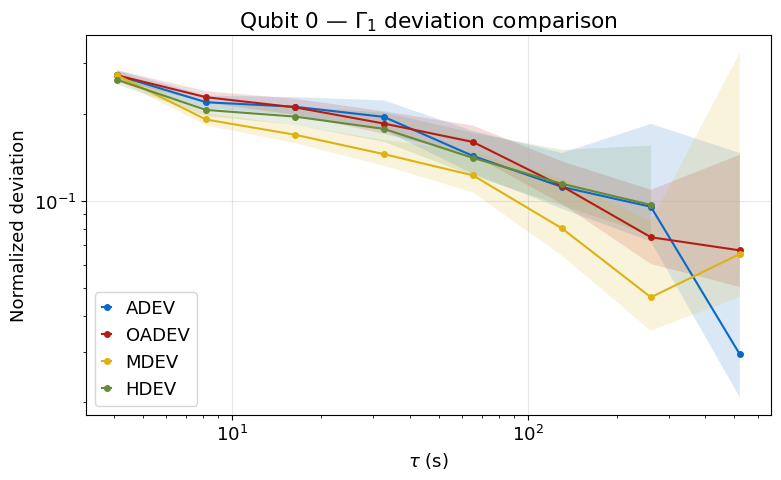

In [486]:
# Compare deviation types (ADEV, OADEV, MDEV, HDEV) for Gamma1
for qi in range(len(tt)):
    data = np.array(tt[qi]['Gamma1'])
    times = np.array(tt[qi]['time'])
    rate = 1.0 / np.mean(np.diff(times))
    plot_deviation_comparison(
        data, rate=rate,
        dev_types=('adev', 'oadev', 'mdev', 'hdev'),
        taus='octave', show_ci=True,
        title=f'Qubit {qi} — $\\Gamma_1$ deviation comparison',
    )
    plt.show()

## Time series and histograms

Number of bad inds for t1 is 48
Number of bad inds for t2 is 67
Number of bad inds for tphi is 68
Number of bad inds for f_ge is 69


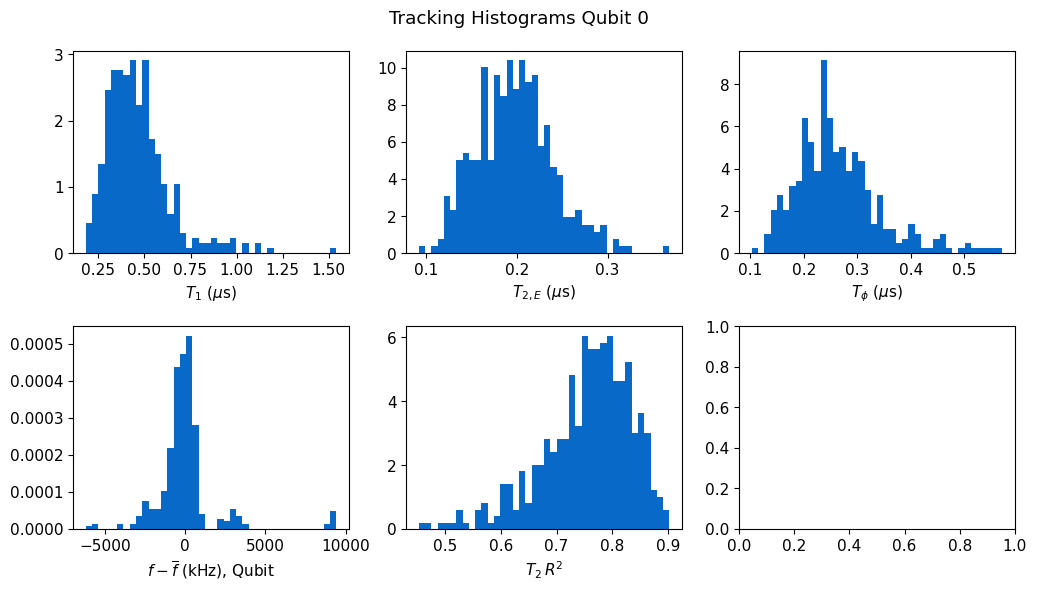

In [487]:
collections.plot_all(tt, param_keys=['t1', 't2', 'tphi', 'f_ge', 't2_r2'], save_path=csv_pth, tracking_id=tracking_id)
plt.show()

Number of bad inds for Gamma1 is 47
Number of bad inds for Gamma2 is 68
Number of bad inds for Gammaphi is 68
Number of bad inds for f_ge is 69


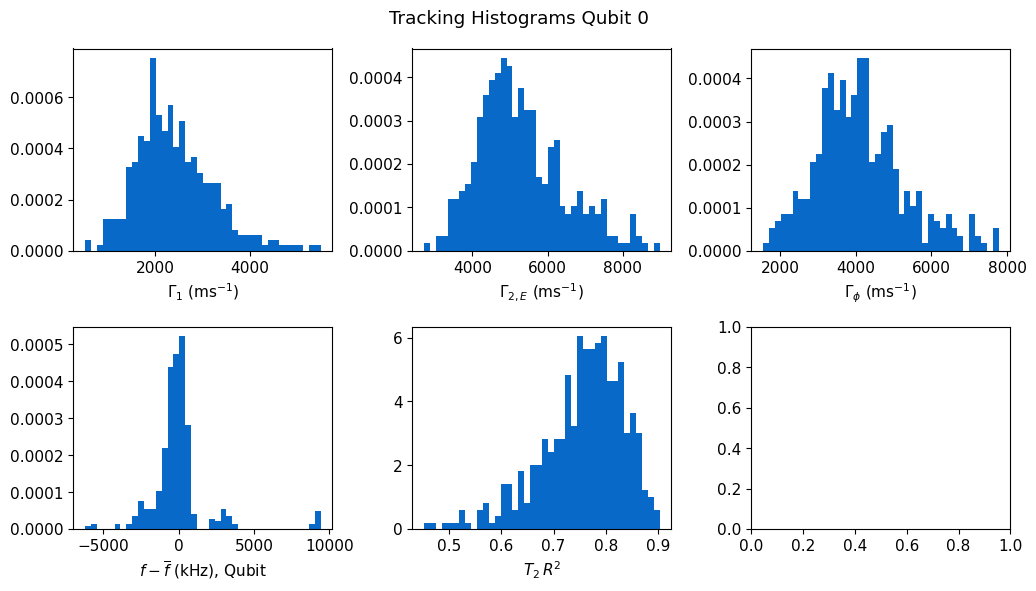

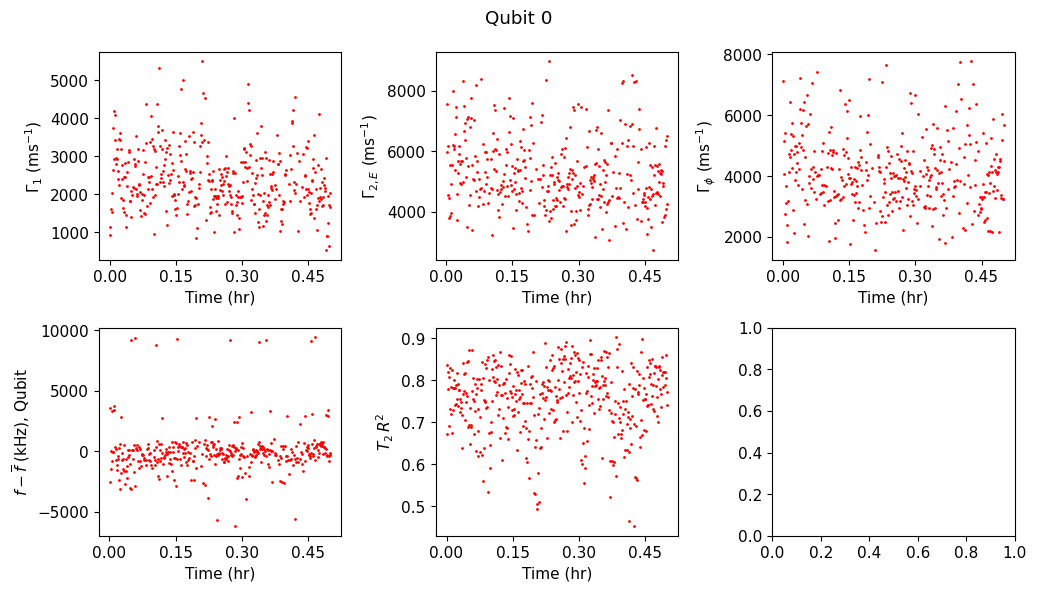

In [488]:
collections.plot_all(tt, param_keys=['Gamma1', 'Gamma2', 'Gammaphi', 'f_ge','t2_r2'], plot_time=True, save_path=csv_pth, tracking_id=tracking_id)
plt.show()

## Violin plots

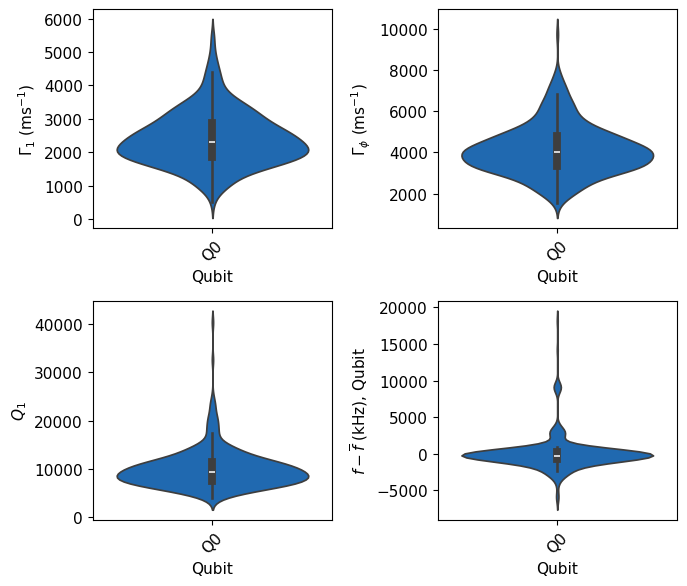

In [489]:
collections.plot_violin(tt, param_keys=['Gamma1', 'Gammaphi', 'q', 'f_ge'], csv_path=csv_pth)
plt.show()

## Power Spectral Density Analysis

Median time between measurements: 4.1 s
Sampling frequency: 0.2455 Hz

Analyzing Gamma1...


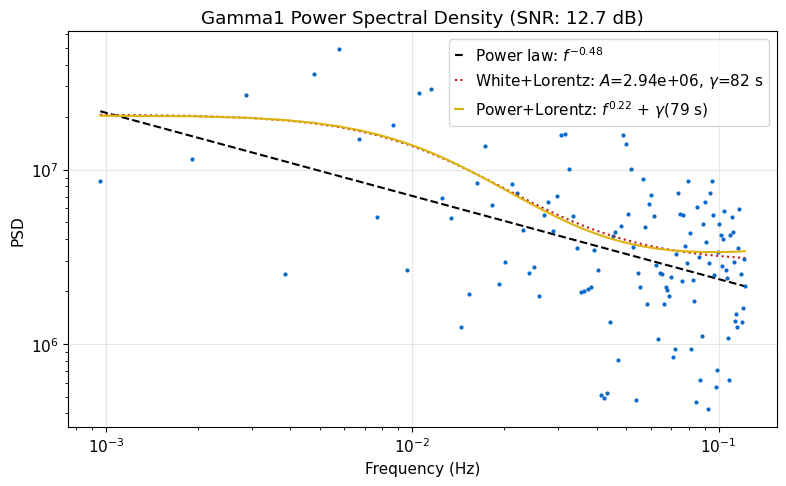

Peak frequency: 5.7535e-03 Hz (Period: 173.8 s)
Total power: 6.7266e+05
SNR: 12.7 dB

Analyzing Gammaphi...


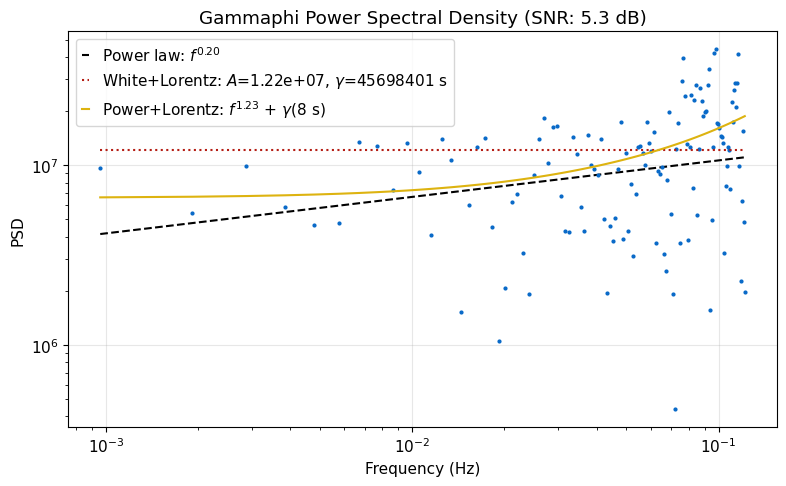

Peak frequency: 9.7809e-02 Hz (Period: 10.2 s)
Total power: 1.4878e+06
SNR: 5.3 dB

Analyzing f_ge...


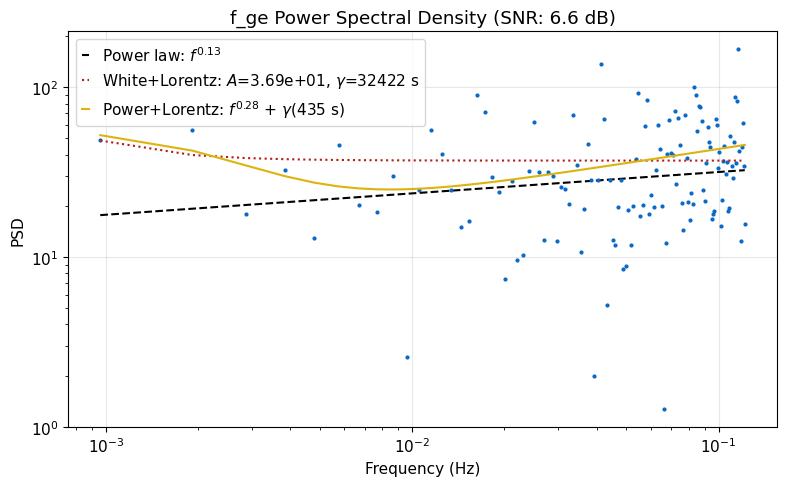

Peak frequency: 1.1603e-01 Hz (Period: 8.6 s)
Total power: 4.5159e+00
SNR: 6.6 dB

Analyzing t1...


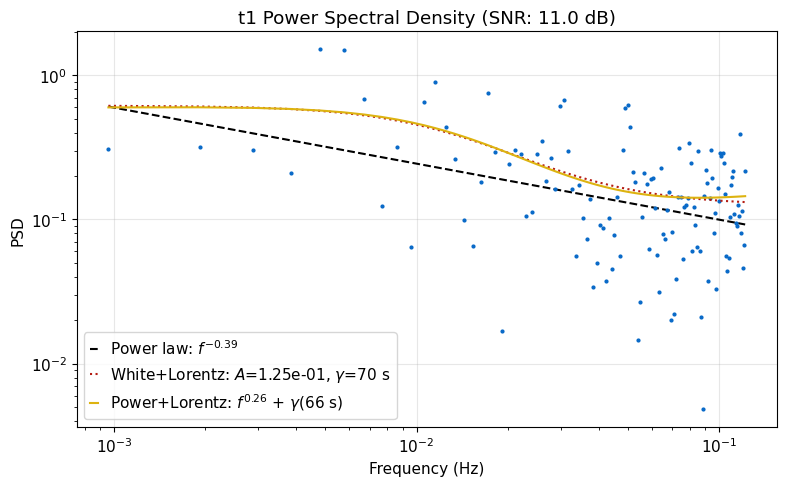

Peak frequency: 4.7946e-03 Hz (Period: 208.6 s)
Total power: 2.5374e-02
SNR: 11.0 dB


In [490]:
from slab_qick_calib.analysis.time_series import analyze_qubit_psd

# Calculate sampling frequency from timestamps
timestamps = tt[0]['time']
dt = np.median(np.diff(timestamps))  # median time between measurements (in seconds)
fs = 1 / dt  # sampling frequency in Hz

print(f"Median time between measurements: {dt:.1f} s")
print(f"Sampling frequency: {fs:.4f} Hz")

# Analyze PSD for different parameters
params_to_analyze = ['Gamma1', 'Gammaphi', 'f_ge', 't1']

for param in params_to_analyze:
    if param in tt[0]:
        data = tt[0][param]
        print(f"\n{'='*60}")
        print(f"Analyzing {param}...")
        results = analyze_qubit_psd(
            data,
            fs=fs,
            parameter_name=param,
            qubit_id=0,
            plot=True,
            save_path=csv_pth,
            tracking_id=tracking_id,
        )
        if results:
            print(f"Peak frequency: {results['peak_freq']:.4e} Hz (Period: {1/results['peak_freq']:.1f} s)")
            print(f"Total power: {results['total_power']:.4e}")
            print(f"SNR: {results['snr_db']:.1f} dB")

## Parameter vs MXC temperature

In [491]:
collections.plot_vs_temperature(tt, param_keys=['t1', 'tphi', 'f_ge', 'Gamma1'], save_path=csv_pth, tracking_id=tracking_id)

[(<Figure size 700x600 with 4 Axes>,
  array([<Axes: xlabel='MXC Temp (mK)', ylabel='$T_1$ ($\\mu$s)'>,
         <Axes: xlabel='MXC Temp (mK)', ylabel='$T_{\\phi}$ ($\\mu$s)'>,
         <Axes: xlabel='MXC Temp (mK)', ylabel='$f-\\overline{f}$ (kHz), Qubit '>,
         <Axes: xlabel='MXC Temp (mK)', ylabel='$\\Gamma_1$ (ms$^{-1}$)'>],
        dtype=object))]

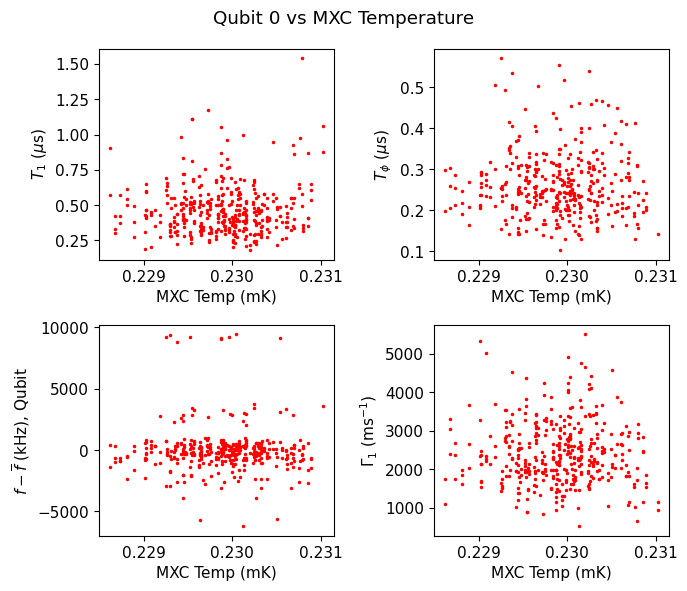

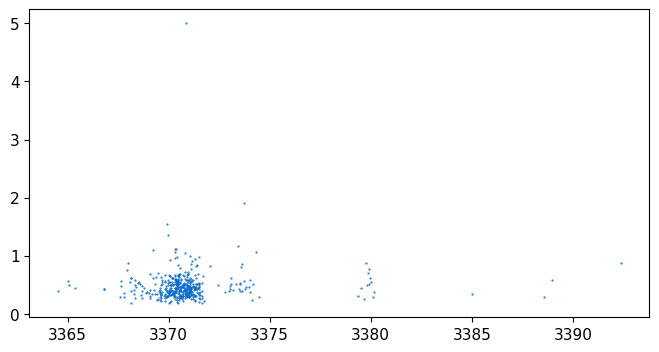

In [492]:
for t in tt:
    plt.figure()
    plt.plot(t['f_ge'], t['t1'], '.')
    plt.show()

## Random scan overlays

In [493]:
import h5py
from pathlib import Path
from slab_qick_calib.analysis.fitting import expfunc, decaysin, decayslopesin
from slab_qick_calib.analysis.collections import detect_t2_type

tracking_dir = Path(expt_path) / 'Tracking' / tracking_id
N_SCANS = 10

def load_scan(fpath):
    with h5py.File(fpath, 'r') as f:
        return {
            'xpts': f['xpts'][:],
            'avgi': f['avgi'][:],
            'fit': f['fit_avgi'][:],
        }

def t2_fit(x, fit):
    return decayslopesin(x, *fit) if len(fit) == 6 else decaysin(x, *fit)

qubits = [qi for qi, _ in enumerate(tt)]
colors = plt.cm.viridis(np.linspace(0, 1, N_SCANS))

T2_LABELS = {'T2e': '$T_{2,E}$', 'T2r': '$T_{2,R}$'}

for qi in qubits:
    # Auto-detect T2 type from HDF5 filenames
    t2_type = detect_t2_type(tracking_dir, qi)

    for expt_type, label, fit_fn in [
        (f't1_qubit{qi}', '$T_1$', lambda x, fit: expfunc(x, *fit)),
        (f'{t2_type}_qubit{qi}', T2_LABELS[t2_type], t2_fit),
    ]:
        files = sorted(tracking_dir.glob(f'{expt_type}_*'))
        if not files:
            print(f'No {label} files found for qubit {qi}')
            continue

        chosen = np.random.choice(len(files), size=min(N_SCANS, len(files)), replace=False)
        chosen_files = [files[i] for i in sorted(chosen)]

        fig, ax = plt.subplots()
        scan_labels = []
        for color, fpath in zip(colors, chosen_files):
            scan_num = int(fpath.stem.split('_')[-1])
            scan_labels.append(str(scan_num))
            d = load_scan(fpath)
            ax.plot(d['xpts'], d['avgi'], '.-', color=color, alpha=0.5, markersize=3)
            x_fit = np.linspace(d['xpts'][0], d['xpts'][-1], 300)
            ax.plot(x_fit, fit_fn(x_fit, d['fit']), '-', color=color, alpha=0.8, lw=1,
                    label=scan_num)

        ax.set_xlabel(r'Delay ($\mu$s)')
        ax.set_ylabel('Avg I (a.u.)')
        ax.set_title(f'Qubit {qi} — {label}  |  scans: {", ".join(scan_labels)}')
        plt.tight_layout()
        plt.show()


No $T_1$ files found for qubit 0
No $T_{2,E}$ files found for qubit 0


In [494]:
# import time
# while True:
#     tt, csv_pth, tt_stats, tracking_id = load_tracking(csv_dir)
#     tt, tt_ave = collections.process_data(tt)
#     tt = collections.add_losses(tt)
#     allan.perform_analysis(tt, param='Gamma1', save_path=csv_pth, tracking_id=tracking_id)
#     collections.plot_all(tt, param_keys=['t1', 'tphi', 'f_ge', 't2_r2'], save_path=csv_pth, tracking_id=tracking_id)
#     plt.show()
#     time.sleep(600)

In [495]:
qubit_list=[0,1,2]

## Save stats to model config

In [496]:
tracking_dir = os.path.join(expt_path, 'Tracking', tracking_id)
qubit_params.stats(cfg_path, tt_stats, qubit_list, tracking_dir=tracking_dir)

KeyError: 1

In [ ]:
np.array([0.0432, 0.0578, 0.2474])/np.array([0.3824, 0.4728, 1.5167])

array([0.11297071, 0.12225042, 0.16311729])

In [ ]:
np.sqrt(3)*0.12

np.float64(0.20784609690826525)